# L3 —— B细胞的亚群识别

In [1]:
import os, re
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
from scipy.sparse import issparse
import matplotlib.pyplot as plt
import omicverse as ov

# 路径与文件
DATA_ROOT = "/mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data"
ANNO_DIR  = os.path.join(DATA_ROOT, "06_annotation/L3/immune"); os.makedirs(ANNO_DIR, exist_ok=True)
FIG_DIR   = os.path.join(ANNO_DIR, "figs");          os.makedirs(FIG_DIR,  exist_ok=True)
IN_PATH   = os.path.join(ANNO_DIR, "L3_immune_annotated.h5ad")
OUT_H5AD  = os.path.join(ANNO_DIR, "L3_B_annotated.h5ad")
OUT_CSV   = os.path.join(ANNO_DIR, "L3_B_summary.csv")

/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## 数据读取


In [2]:
adata = sc.read_h5ad(IN_PATH)
adata

AnnData object with n_obs × n_vars = 187365 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'GSE_colors', 'L1_lineage_colors', 'L2_celltype_colors', 'L2_celltype_sub_colors', 'REFERENCE_MANU', 'hvg', 'leiden_0.2', 'leiden_0.4', 'leiden_0.4_colors', 'leiden_0.6', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

## 查看L2注释结果

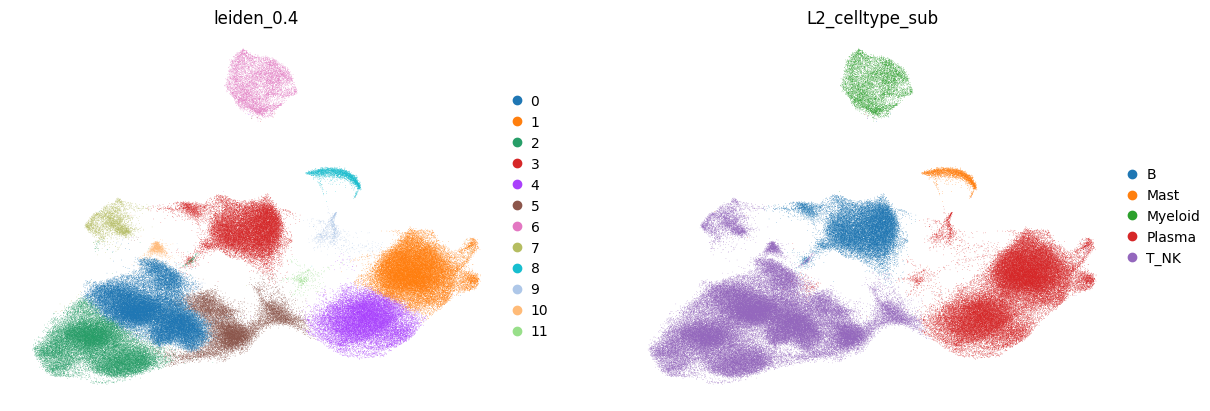

In [3]:
sc.pl.umap(adata,
           color=["leiden_0.4","L2_celltype_sub"],
           frameon=False,
)

In [4]:
adata.obs["L2_celltype_sub"].value_counts()

L2_celltype_sub
T_NK       95433
Plasma     58095
B          23996
Myeloid     7272
Mast        2569
Name: count, dtype: int64

## 对B细胞进行细分

In [5]:
sub = adata[adata.obs["L2_celltype_sub"]=="B"].copy()
sub

AnnData object with n_obs × n_vars = 23996 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'GSE_colors', 'L1_lineage_colors', 'L2_celltype_colors', 'L2_celltype_sub_colors', 'REFERENCE_MANU', 'hvg', 'leiden_0.2', 'leiden_0.4', 'leiden_0.4_colors', 'leiden_0.6', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

简化一下亚群对象

In [6]:
# 1. 删除之前的降维
for key in ["X_pca", "X_pca_harmony", "X_scVI", "X_umap"]:
    if key in sub.obsm:
        del sub.obsm[key]
# 2. 删除之前的 graph（neighbors）
for key in ["neighbors"]:
    if key in sub.uns:
        del sub.uns[key]
for key in ["distances", "connectivities"]:
    if key in sub.obsp:
        del sub.obsp[key]
# 4. 删除 var 中不再需要的高变基因标记
for key in ["highly_variable", "highly_variable_rank",
            "means", "variances", "variances_norm"]:
    if key in sub.var:
        del sub.var[key]
# 5. 删除 uns 中各种配色、聚类结果、rank_genes_groups
keys_to_remove = [
    k for k in sub.uns.keys()
    if ("colors" in k) or ("leiden" in k) or ("rank_genes_groups" in k)
]
for k in keys_to_remove:
    del sub.uns[k]
sub

AnnData object with n_obs × n_vars = 23996 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt'
    uns: 'REFERENCE_MANU', 'hvg', 'log1p', 'umap'
    layers: 'counts'

In [7]:
# 若有原始计数，先切回 counts 再开始标准流程
if "counts" in sub.layers:
    sub.X = sub.layers["counts"]

## HVG → PCA → Harmony → neighbors → leiden

In [8]:
sc.pp.normalize_total(sub, target_sum=1e4)
sc.pp.log1p(sub)
sub

AnnData object with n_obs × n_vars = 23996 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt'
    uns: 'REFERENCE_MANU', 'hvg', 'log1p', 'umap'
    layers: 'counts'

In [9]:
# 标记 HVG，但不裁剪基因
sc.pp.highly_variable_genes(
    sub, n_top_genes=2000, flavor="seurat_v3",
    subset=False, span=0.5, check_values=False
)
hv_mask = sub.var["highly_variable"].values

In [10]:
# 仅在 HVG 上做 PCA（不丢非HVG；把结果写回到 sub）
sub_hv = sub[:, hv_mask].copy()
sc.pp.scale(sub_hv, max_value=10)
sc.tl.pca(sub_hv, n_comps=50, svd_solver="arpack")
sub.obsm["X_pca"] = sub_hv.obsm["X_pca"]
sub

AnnData object with n_obs × n_vars = 23996 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'REFERENCE_MANU', 'hvg', 'log1p', 'umap'
    obsm: 'X_pca'
    layers: 'counts'

根据不同的数据集批次去除批次效应

In [11]:
# Harmony 去批次（基于 PCA）
sce.pp.harmony_integrate(sub, key="GSE", basis="X_pca")
sub

2025-12-01 19:47:52,719 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-12-01 19:47:55,023 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-12-01 19:47:55,124 - harmonypy - INFO - Iteration 1 of 10
2025-12-01 19:48:01,853 - harmonypy - INFO - Iteration 2 of 10
2025-12-01 19:48:07,285 - harmonypy - INFO - Converged after 2 iterations


AnnData object with n_obs × n_vars = 23996 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'REFERENCE_MANU', 'hvg', 'log1p', 'umap'
    obsm: 'X_pca', 'X_pca_harmony'
    layers: 'counts'

In [12]:
# 邻域/聚类/UMAP
sc.pp.neighbors(sub, use_rep="X_pca_harmony", n_neighbors=20)
sc.tl.umap(sub)

In [13]:
sc.tl.leiden(sub, resolution=0.2, key_added=f"leiden_0.2_B")
sc.tl.leiden(sub, resolution=0.4, key_added=f"leiden_0.4_B")

查看批次效应

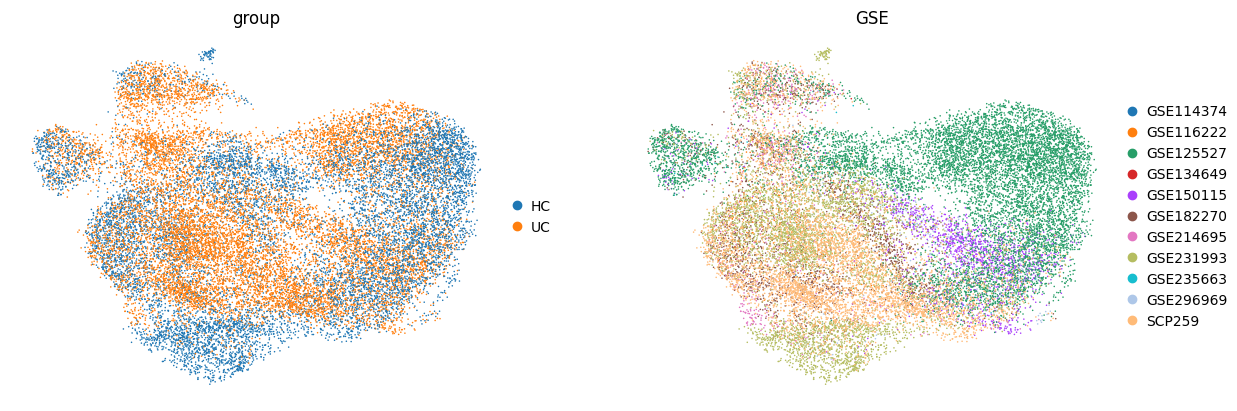

In [14]:
sc.pl.umap(sub, color=['group','GSE'], frameon=False)

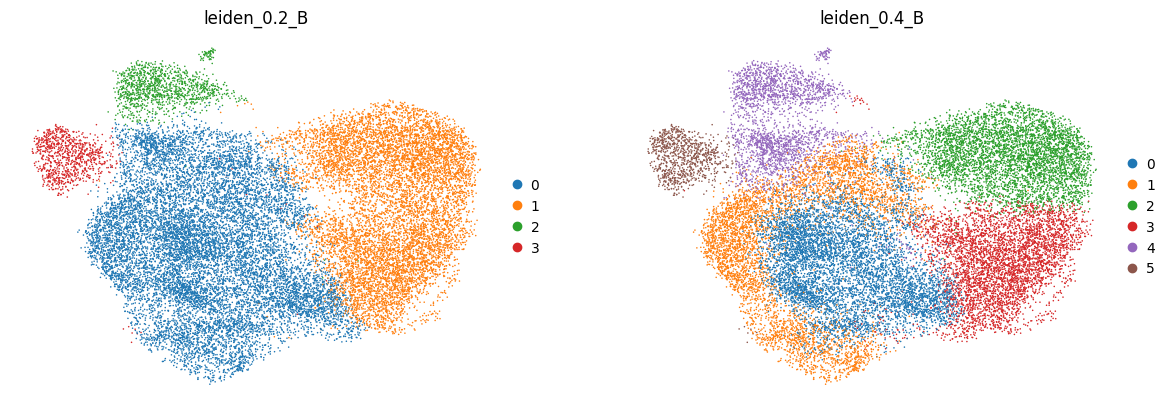

In [15]:
sc.pl.umap(sub, color=['leiden_0.2_B','leiden_0.4_B'], frameon=False)

## 查看marker表达

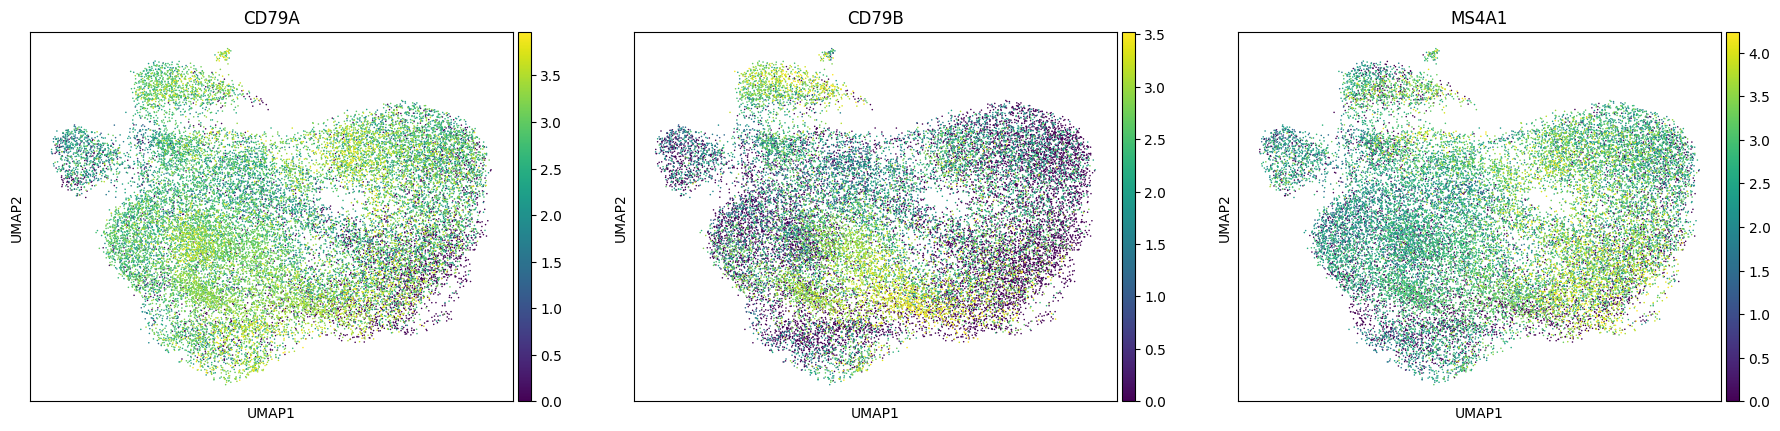

In [17]:
Lineage = ["CD79A", "CD79B", "MS4A1"]
def safe_genes(genes, sub):
    return [g for g in genes if g in adata.var_names]

sc.pl.umap(sub, color=safe_genes(Lineage, sub), ncols=3, cmap="viridis", vmax="p99", vmin=0, size=5,)

In [18]:
l3_b_markers = {
    # --- 基础 B 细胞 ---
    "Naive_B": ["IGHD", "TCL1A", "FCER2", "IL4R", "MS4A1"],
    "Memory_B": ["CD27", "AIM2", "TNFRSF13B", "MS4A1"],
    
    # --- 浆细胞 (重点区分 Isotype) ---
    "Plasma_IgA": ["IGHA1", "IGHA2", "JCHAIN", "MZB1"],
    "Plasma_IgG": ["IGHG1", "IGHG2", "IGHG3", "IGHG4", "MZB1"],
    
    # --- 状态/其他 ---
    "GC_B": ["BCL6", "AICDA"], # 视样本来源而定，不一定有
    "Cycling_B": ["MKI67", "TOP2A"],
    
    # --- 泛标记 (用于质控) ---
    "Pan_B": ["CD79A", "CD79B", "MS4A1"], # 注意浆细胞 MS4A1 往往阴性
    "Pan_Plasma": ["SDC1", "XBP1", "DERL3"]
}
# 辅助函数：检查基因是否存在于数据集中，防止报错
def safe_genes(genes, sub):
    valid_genes = [g for g in genes if g in sub.var_names]
    if len(valid_genes) < len(genes):
        print(f"Warning: 忽略了缺失基因: {set(genes) - set(valid_genes)}")
    return valid_genes

正在绘制 Pan_Plasma Markers...


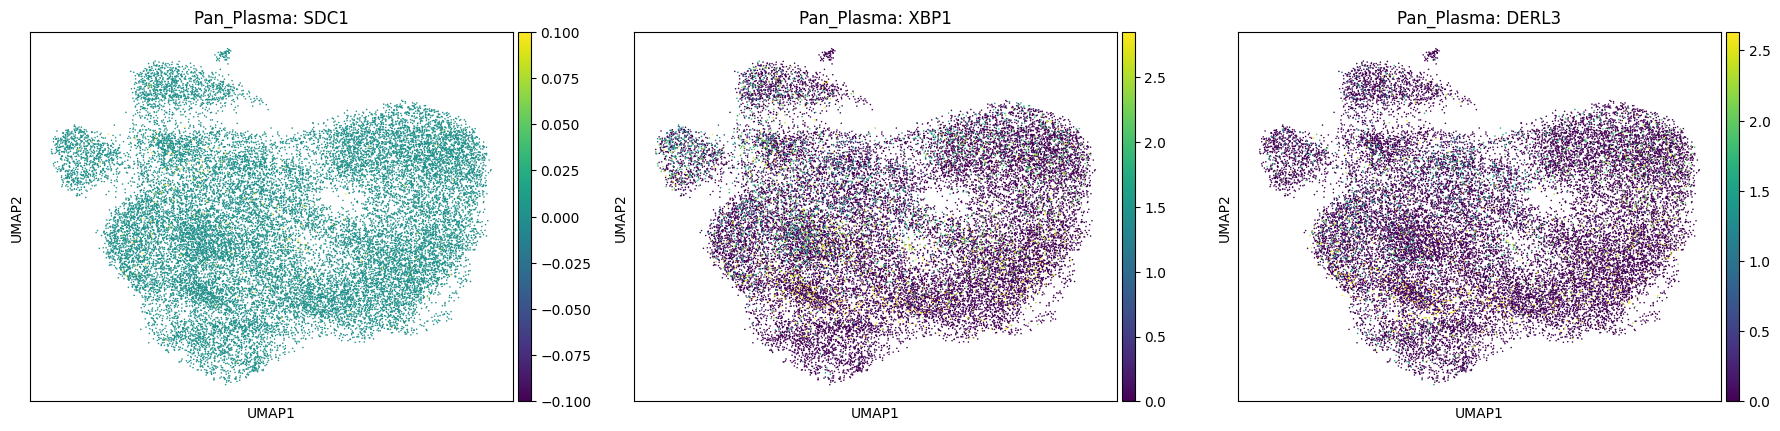

In [31]:
print("正在绘制 Pan_Plasma Markers...")
sc.pl.umap(sub, 
           color=safe_genes(l3_b_markers["Pan_Plasma"], sub), 
           ncols=3, cmap="viridis", vmax="p99", vmin=0, size=5, 
           title=[f"Pan_Plasma: {g}" for g in safe_genes(l3_b_markers["Pan_Plasma"], sub)])

### Naive B
- FCER2:低亲和力 IgE 受体。CD23 主要表达于成熟的初始 B 细胞表面。它不仅调节 IgE 的合成，还参与 B 细胞的存活和增殖信号。高表达 FCER2 是成熟初始 B 细胞（Follicular B cells）的典型特征。
- IL4R:细胞因子受体。IL-4 是 T 细胞辅助 B 细胞活化和增殖的关键细胞因子。初始 B 细胞高表达 IL-4 受体，处于“时刻准备着”接收 T 细胞信号的状态。
- MS4A1:泛 B 细胞标志 (Pan-B)。CD20 从前 B 细胞阶段开始表达，直到分化为浆细胞前都会维持高表达。它在这里的作用是确认细胞谱系（确认为 B 细胞），并与浆细胞（CD20 阴性）区分开来。

正在绘制 Naive_B Markers...


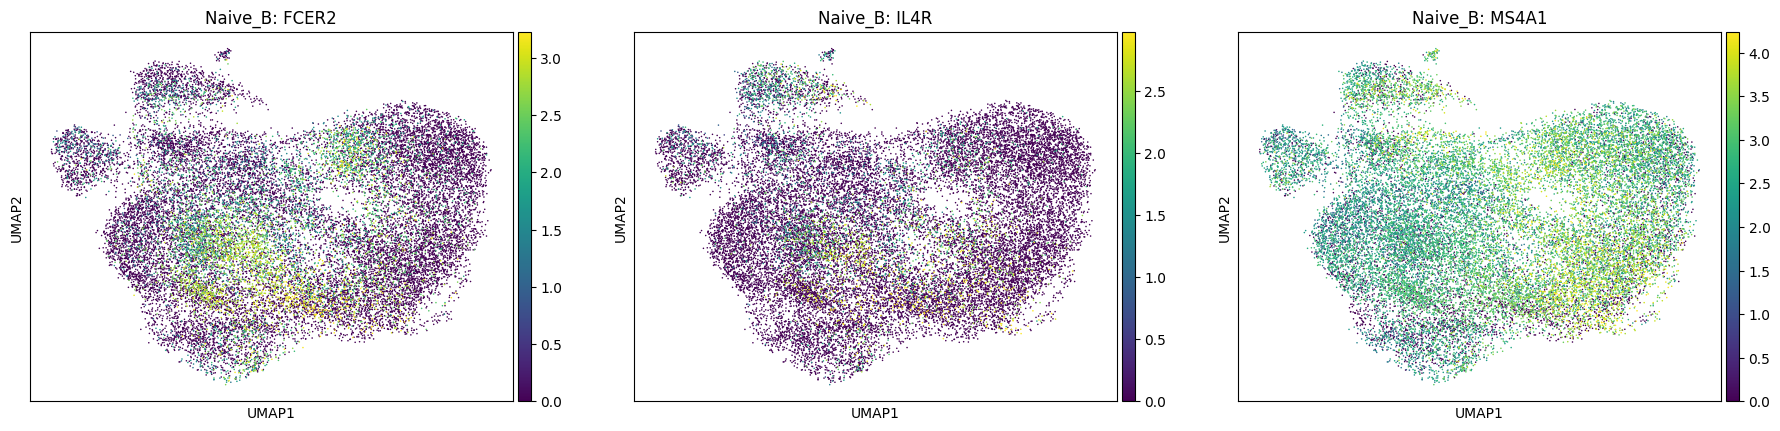

In [19]:
print("正在绘制 Naive_B Markers...")
sc.pl.umap(sub, 
           color=safe_genes(l3_b_markers["Naive_B"], sub), 
           ncols=3, cmap="viridis", vmax="p99", vmin=0, size=5, 
           title=[f"Naive_B: {g}" for g in safe_genes(l3_b_markers["Naive_B"], sub)])

细胞群0可能是Naive B

### Memory_B
- CD27：记忆 B 细胞最经典的表面标志。在 B 细胞发育中，CD27 的表达标志着细胞经历了抗原刺激和生发中心反应，从初始（Naive）状态转变为记忆（Memory）状态。在 scRNA-seq 分析中，CD27 高表达是区分 Memory B 和 Naive B（通常为 CD27-）的“金标准”。
- AIM2：DNA 识别受体/记忆特异性基因。虽然 AIM2 最为人知的功能是作为炎症小体识别胞质 DNA，但在 B 细胞生物学中，它被发现在 记忆 B 细胞 中特异性高表达（相比于 Naive B）。它有助于抑制 B 细胞过度活化，维持记忆 B 细胞的长期存活。在转录组数据中，它是区分 Memory vs Naive 的一个非常灵敏的差异基因。
- TNFRSF13B：生存与分化受体。它是 BAFF 和 APRIL（B 细胞活化因子）的受体。TACI 主要在记忆 B 细胞和边缘区 B 细胞上表达，而在初始 B 细胞上表达较低。它的信号对于维持记忆 B 细胞的存活以及后续向浆细胞的分化至关重要。

正在绘制 Memory_B Markers...


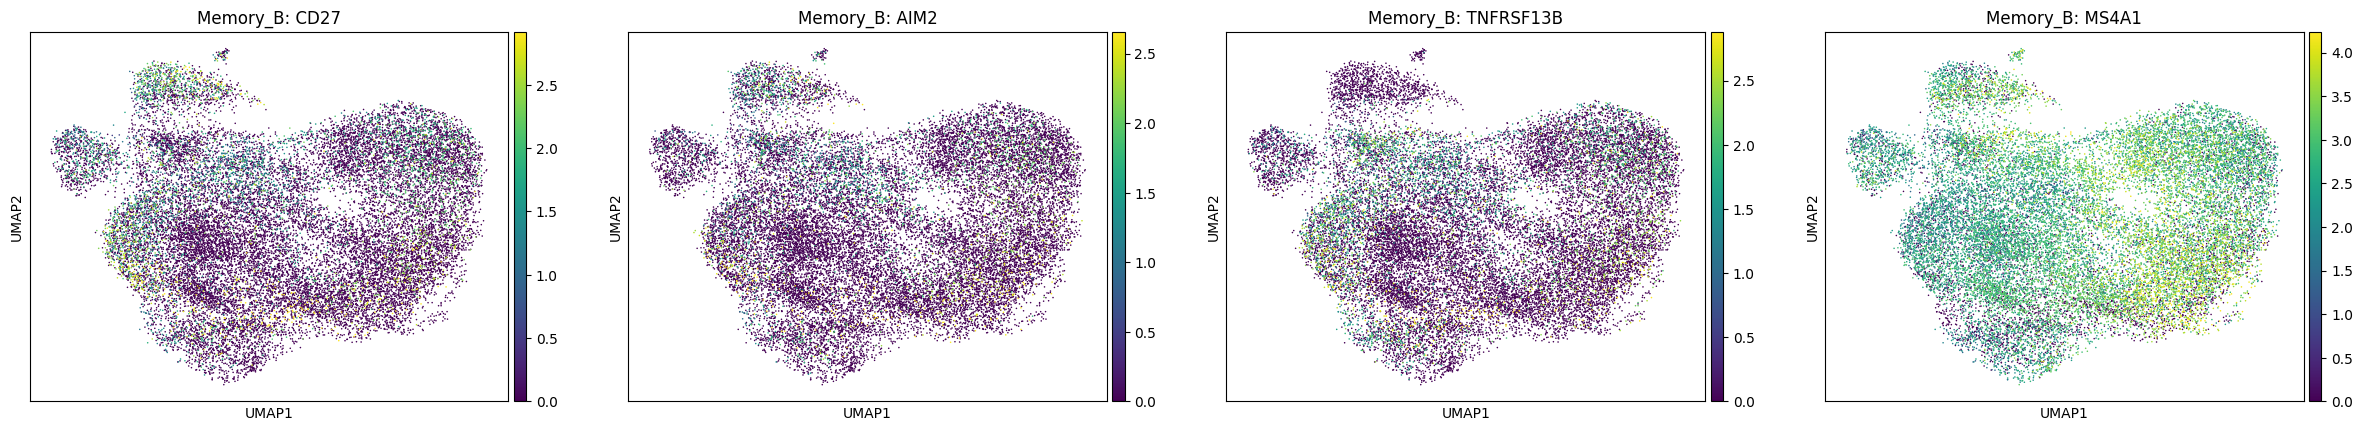

In [21]:
print("正在绘制 Memory_B Markers...")
sc.pl.umap(sub, 
           color=safe_genes(l3_b_markers["Memory_B"], sub), 
           ncols=4, cmap="viridis", vmax="p99", vmin=0, size=5, 
           title=[f"Memory_B: {g}" for g in safe_genes(l3_b_markers["Memory_B"], sub)])

细胞群1可能是Memory_B

### GC_B(生发中心 B 细胞)
- BCL6:生发中心的主宰转录因子。BCL6 是 GC B 细胞身份的必需调控因子


正在绘制 GC_B Markers...


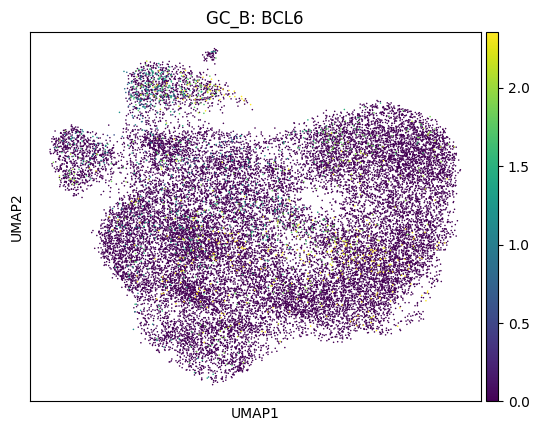

In [22]:
print("正在绘制 GC_B Markers...")
sc.pl.umap(sub, 
           color=safe_genes(l3_b_markers["GC_B"], sub), 
           ncols=4, cmap="viridis", vmax="p99", vmin=0, size=5, 
           title=[f"GC_B: {g}" for g in safe_genes(l3_b_markers["GC_B"], sub)])

正在绘制 Cycling_B Markers...


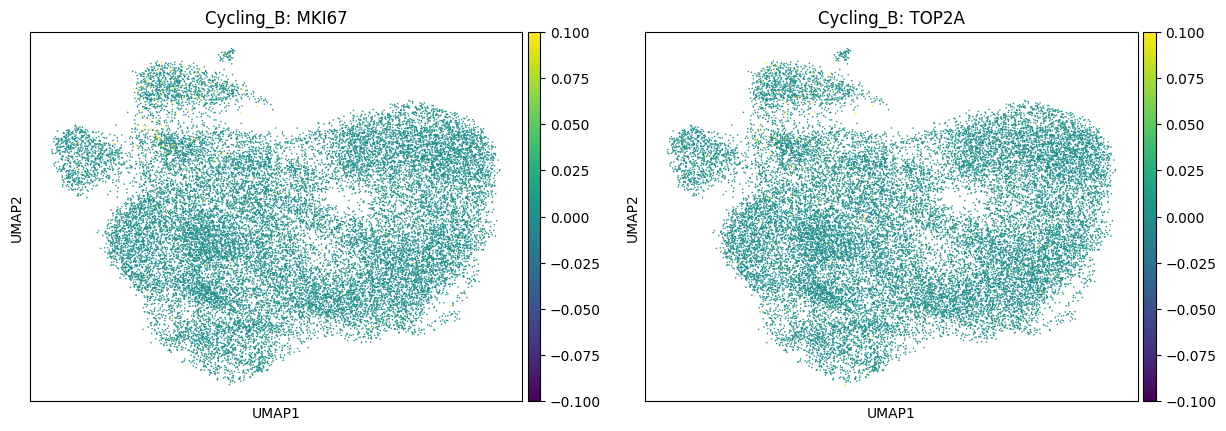

In [23]:
print("正在绘制 Cycling_B Markers...")
sc.pl.umap(sub, 
           color=safe_genes(l3_b_markers["Cycling_B"], sub), 
           ncols=4, cmap="viridis", vmax="p99", vmin=0, size=5, 
           title=[f"Cycling_B: {g}" for g in safe_genes(l3_b_markers["Cycling_B"], sub)])

正在绘制 Plasma_IgA Markers...


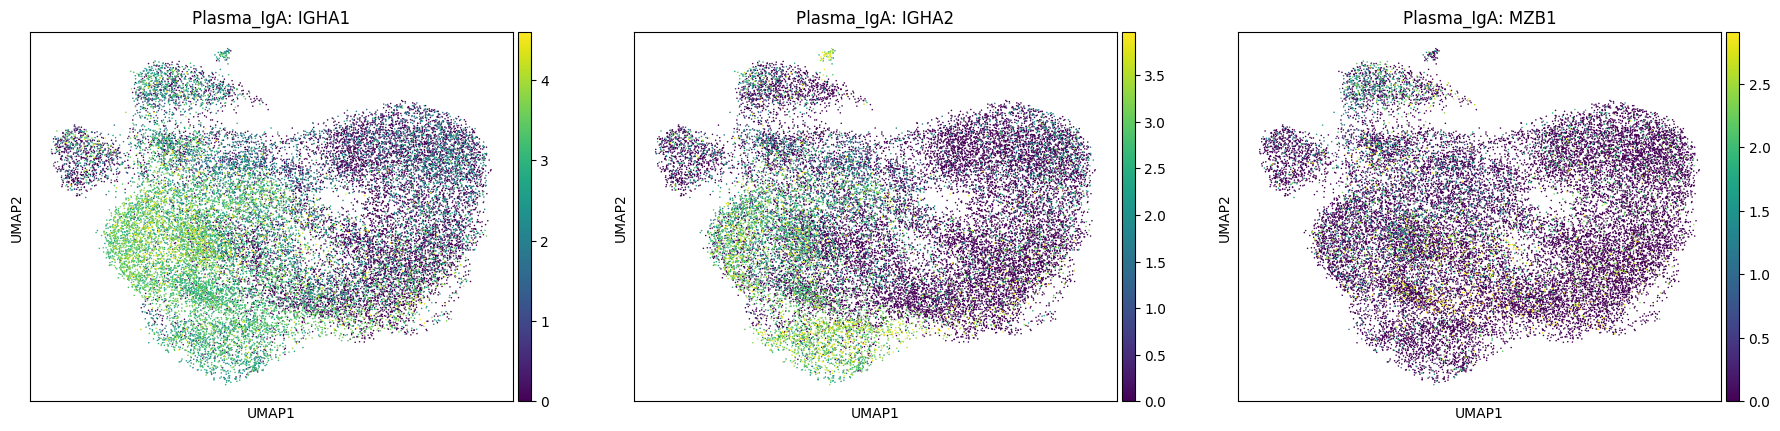

In [28]:
print("正在绘制 Plasma_IgA Markers...")
sc.pl.umap(sub, 
           color=safe_genes(l3_b_markers["Plasma_IgA"], sub), 
           ncols=4, cmap="viridis", vmax="p99", vmin=0, size=5, 
           title=[f"Plasma_IgA: {g}" for g in safe_genes(l3_b_markers["Plasma_IgA"], sub)])

## 差异分析

In [24]:
sub

AnnData object with n_obs × n_vars = 23996 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub', 'leiden_0.2_B', 'leiden_0.4_B'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'REFERENCE_MANU', 'hvg', 'log1p', 'umap', 'neighbors', 'leiden_0.2_B', 'leiden_0.4_B', 'group_colors', 'GSE_colors', 'leiden_0.2_B_colors', 'leiden_0.4_B_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

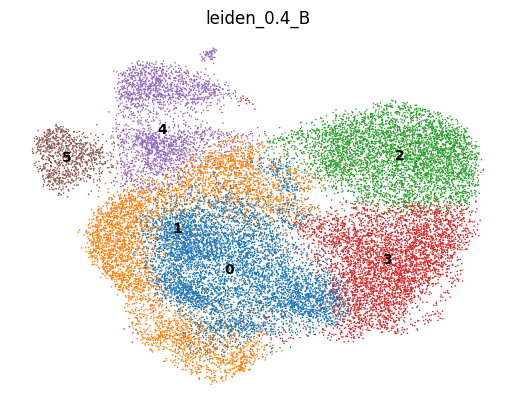

In [25]:
sc.pl.umap(sub, color=['leiden_0.4_B'], frameon=False, ncols=2, legend_loc='on data')

In [26]:
if 'leiden_0.4_B' in sub.obs.columns:
    sub.obs['leiden_0.4_B'] = sub.obs['leiden_0.4_B'].astype('category')

# 2. 运行差异分析
print("正在进行差异基因分析...")
sc.tl.rank_genes_groups(
    sub, 
    groupby='leiden_0.4_B', 
    method='wilcoxon', 
    use_raw=True, 
    pts=True
)
print("分析完成！")

正在进行差异基因分析...
分析完成！


In [27]:
# 获取所有分组的名称
groups = sub.obs['leiden_0.4_B'].cat.categories

# 初始化一个字典来存储结果
top10_genes = {}

print("=== 各亚群 Top 10 差异基因 (基于 Score 排序) ===")
for group in groups:
    # 提取该群的差异基因数据框
    df = sc.get.rank_genes_groups_df(sub, group=group)
    
    # 筛选条件：通常我们关注上调的基因 (logfoldchanges > 0)
    # 按 score 降序排列（score 综合了表达差异和显著性）
    top_genes = df[df['logfoldchanges'] > 0].sort_values('scores', ascending=False).head(10)['names'].tolist()
    
    top10_genes[group] = top_genes
    print(f"Cluster {group}: {', '.join(top_genes)}")

# 如果你想把这个 Top10 列表存成一个 DataFrame 方便查看：
df_top10 = pd.DataFrame(top10_genes)
print("\nTop 10 基因表格预览：")
#display(df_top10)

# 可选：保存到 CSV
# df_top10.to_csv("L3_TNK_Top10_Markers.csv")

=== 各亚群 Top 10 差异基因 (基于 Score 排序) ===
Cluster 0: HLA-DPB1, HLA-DRB1, HLA-DPA1, HLA-DQB1, HLA-DQA1, RPL21, RPL26, HLA-DRA, IGHM, HLA-DMA
Cluster 1: RPL21, RPL26, RPS10, RPL27A, RPS20, IGHA1, RPS29, IGHA2, RPL13A, MT-ND2
Cluster 2: EEF1A1, RPL13, RPL30, CD74, RPL7A, RPS12, RPS3, RPL19, RPLP1, RPS23
Cluster 3: FOS, FOSB, JUN, PPP1R15A, MS4A1, KLF6, DUSP1, HSP90AA1, KLF2, MTRNR2L12
Cluster 4: ACTG1, GAPDH, ARPC2, SERF2, LRMP, ARPC5, ARPC1B, CORO1A, CFL1, PRDX1
Cluster 5: TNFAIP3, IL32, IL7R, CD3E, SRGN, CD3D, ANXA1, RGCC, IFITM1, JUN

Top 10 基因表格预览：


### 针对第1群细胞进行差异分析

In [30]:
# 1. 运行差异分析 (Cluster 1 vs. Rest)
# ==============================================
print("正在对 Cluster 1 进行差异分析...")

# sc.tl.rank_genes_groups 用于计算差异基因
# groups=['0']: 指定只计算第 0 群
# reference='rest': 指定对比对象为“其余所有细胞”
sc.tl.rank_genes_groups(
    sub, 
    groupby='leiden_0.4_B', 
    groups=['1'],      
    reference='rest',  
    method='wilcoxon', # 推荐使用的统计检验方法
    use_raw=True,      # 使用标准化后的原始数据(log-transformed)
    pts=True           # 计算基因在组内/组外的表达比例(pct)
)

# ==============================================
# 2. 提取并整理 Top 10 Marker
# ==============================================
# 获取结果 DataFrame
c0_df = sc.get.rank_genes_groups_df(sub, group='1')

# 筛选标准：
# - logfoldchanges > 0.25 (过滤掉差异太小的)
# - pvals_adj < 0.05 (过滤掉不显著的)
# 按 score (综合得分) 降序排列，取前 10 个
top10_c0 = c0_df[
    (c0_df['logfoldchanges'] > 0.25) & 
    (c0_df['pvals_adj'] < 0.05)
].sort_values('scores', ascending=False).head(10)

# ==============================================
# 3. 打印结果
# ==============================================
print("\n=== Cluster 0 Top 10 特异性 Marker ===")
# 格式化展示：基因名 | Log2倍数变化 | 调整后P值 | 组内表达比例 | 组外表达比例
print(top10_c0[['names', 'logfoldchanges', 'pvals_adj', 'pct_nz_group', 'pct_nz_reference']].to_string(index=False))

正在对 Cluster 1 进行差异分析...

=== Cluster 0 Top 10 特异性 Marker ===
 names  logfoldchanges  pvals_adj  pct_nz_group  pct_nz_reference
 RPL21        2.195079        0.0      0.940606          0.656253
 RPL26        1.378541        0.0      0.986667          0.834558
 RPS10        2.085417        0.0      0.877374          0.505250
RPL27A        1.230681        0.0      0.991919          0.881025
 RPS20        1.375942        0.0      0.983030          0.812244
 IGHA1        2.062789        0.0      0.897374          0.518482
 RPS29        1.321638        0.0      0.980202          0.868529
 IGHA2        2.459040        0.0      0.668889          0.252389
RPL13A        1.002707        0.0      0.999596          0.965662
MT-ND2        2.084311        0.0      0.847071          0.518902


### 针对第2群细胞进行差异分析

In [33]:
# 1. 运行差异分析 (Cluster 1 vs. Rest)
# ==============================================
print("正在对 Cluster 2 进行差异分析...")

# sc.tl.rank_genes_groups 用于计算差异基因
# groups=['0']: 指定只计算第 0 群
# reference='rest': 指定对比对象为“其余所有细胞”
sc.tl.rank_genes_groups(
    sub, 
    groupby='leiden_0.4_B', 
    groups=['2'],      
    reference='rest',  
    method='wilcoxon', # 推荐使用的统计检验方法
    use_raw=True,      # 使用标准化后的原始数据(log-transformed)
    pts=True           # 计算基因在组内/组外的表达比例(pct)
)

# ==============================================
# 2. 提取并整理 Top 10 Marker
# ==============================================
# 获取结果 DataFrame
c0_df = sc.get.rank_genes_groups_df(sub, group='2')

# 筛选标准：
# - logfoldchanges > 0.25 (过滤掉差异太小的)
# - pvals_adj < 0.05 (过滤掉不显著的)
# 按 score (综合得分) 降序排列，取前 10 个
top10_c0 = c0_df[
    (c0_df['logfoldchanges'] > 0.25) & 
    (c0_df['pvals_adj'] < 0.05)
].sort_values('scores', ascending=False).head(20)

# ==============================================
# 3. 打印结果
# ==============================================
print("\n=== Cluster 0 Top 10 特异性 Marker ===")
# 格式化展示：基因名 | Log2倍数变化 | 调整后P值 | 组内表达比例 | 组外表达比例
print(top10_c0[['names', 'logfoldchanges', 'pvals_adj', 'pct_nz_group', 'pct_nz_reference']].to_string(index=False))

正在对 Cluster 2 进行差异分析...

=== Cluster 0 Top 10 特异性 Marker ===
 names  logfoldchanges  pvals_adj  pct_nz_group  pct_nz_reference
EEF1A1        1.551241        0.0      1.000000          0.963619
 RPL13        1.519350        0.0      1.000000          0.959914
 RPL30        1.270500        0.0      1.000000          0.972572
  CD74        1.319195        0.0      1.000000          0.996295
 RPL7A        1.225745        0.0      0.998466          0.933103
 RPS12        1.208490        0.0      0.999781          0.981732
  RPS3        1.012993        0.0      0.999562          0.977152
 RPL19        0.928150        0.0      1.000000          0.984254
 RPLP1        1.203108        0.0      1.000000          0.985128
 RPS23        1.074428        0.0      0.999781          0.969073
  RPL8        0.885990        0.0      0.999123          0.980291
  RPS8        0.944638        0.0      0.999343          0.981320
  FTH1        1.485751        0.0      0.997589          0.887974
 RPL10        1

## 结果

In [34]:
sub

AnnData object with n_obs × n_vars = 23996 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub', 'leiden_0.2_B', 'leiden_0.4_B'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'REFERENCE_MANU', 'hvg', 'log1p', 'umap', 'neighbors', 'leiden_0.2_B', 'leiden_0.4_B', 'group_colors', 'GSE_colors', 'leiden_0.2_B_colors', 'leiden_0.4_B_colors', 'rank_genes_groups'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [36]:
l3_b_annotation = {
    '0': 'Naive B',        # IgM+, MHC-II high
    '1': 'Plasma IgA',     # IGHA1+, High Protein Synthesis
    '2': 'Low Quality',    # Ribosomal dominant
    '3': 'B_Stress',       # FOS/JUN+, CD20+
    '4': 'GC B',           # LRMP+, Cytoskeleton+
    '5': 'Contaminants'    # CD3+, T cells
}

In [37]:
# 2. 应用注释到新列 'L3'
# ----------------------------------------------------------
# 确保聚类列是字符串类型，以便匹配字典的 Key
cluster_col = 'leiden_0.4_B' 

if cluster_col in sub.obs.columns:
    # 创建新列 L3
    sub.obs['L3'] = sub.obs[cluster_col].astype(str).map(l3_b_annotation)
    
    # 将 L3 转为 category 类型，方便后续绘图和排序
    sub.obs['L3'] = sub.obs['L3'].astype('category')
    
    print("注释已添加至 sub.obs['L3'] 列。")
    
    # 打印注释后的统计信息
    print("\n注释统计 (细胞数):")
    print(sub.obs['L3'].value_counts())

else:
    print(f"错误: 未找到列名 '{cluster_col}'，请检查您的 adata.obs。")

注释已添加至 sub.obs['L3'] 列。

注释统计 (细胞数):
L3
Naive B         6565
Plasma IgA      4950
Low Quality     4563
B_Stress        4466
GC B            2504
Contaminants     948
Name: count, dtype: int64


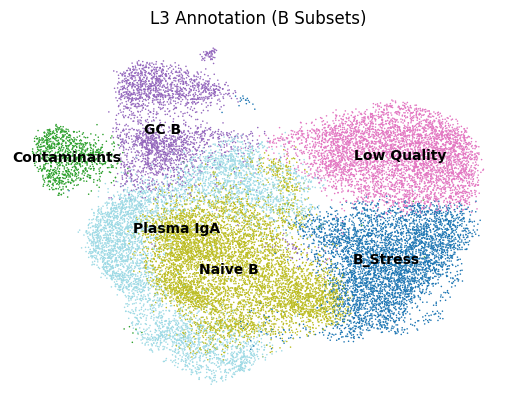

In [38]:
sc.pl.umap(
    sub, 
    color='L3', 
    title='L3 Annotation (B Subsets)', 
    frameon=False, 
    legend_loc='on data',  # 标签直接标在图上
    legend_fontsize=10,
    palette='tab20'        # 使用区分度较高的色板
)

In [39]:
import os
import matplotlib.pyplot as plt

# 绘制并保存 UMAP 图
fig_path = os.path.join(FIG_DIR, "L3_B_annotation_UMAP.png")

sc.pl.umap(
    sub,
    color=["L3"],
    frameon=False,
    title="L3 B annotation",  # 英文标题
    save=None,  # 我们手动保存，不用 Scanpy 自动保存
    show=False  # 防止 Notebook 中立即弹出
)

# 手动保存图片（可控格式和分辨率）
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.close()

print(f"[Saved figure] → {fig_path}")


[Saved figure] → /mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data/06_annotation/L3/immune/figs/L3_B_annotation_UMAP.png


In [40]:
sub

AnnData object with n_obs × n_vars = 23996 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub', 'leiden_0.2_B', 'leiden_0.4_B', 'L3'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'REFERENCE_MANU', 'hvg', 'log1p', 'umap', 'neighbors', 'leiden_0.2_B', 'leiden_0.4_B', 'group_colors', 'GSE_colors', 'leiden_0.2_B_colors', 'leiden_0.4_B_colors', 'rank_genes_groups', 'L3_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [41]:
wanted_cols = [
    "GSM", "GSE", "group",
    "L1_lineage"             
    "L2_celltype_sub",        # 最终子类（回收后已含 Other）
    'L3'
]
out_cols = [c for c in wanted_cols if c in sub.obs.columns]

sub.obs[out_cols].to_csv(OUT_CSV, index=True)
print(f"[Saved per-cell table] -> {OUT_CSV}")

[Saved per-cell table] -> /mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data/06_annotation/L3/immune/L3_B_summary.csv


In [42]:
sub.write_h5ad(OUT_H5AD, compression="gzip")